# Movies Dataset Correlation Analysis

# Objective 

This project explores relationships between movie budget, gross earnings and other numerical variables using correlation analysis.

In [9]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

matplotlib.rcParams['figure.figsize'] = (10,5)
pd.options.mode.chained_assignment = None

In [10]:
movies_df=pd.read_csv('movies.csv')

# Data Cleaning

In [11]:
movies_df.shape

(7668, 15)

In [12]:
pd.isnull(movies_df).sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [13]:
movies_df.dropna(inplace=True)

In [14]:
movies_df.info()

<class 'pandas.DataFrame'>
Index: 5421 entries, 0 to 7652
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      5421 non-null   str    
 1   rating    5421 non-null   str    
 2   genre     5421 non-null   str    
 3   year      5421 non-null   int64  
 4   released  5421 non-null   str    
 5   score     5421 non-null   float64
 6   votes     5421 non-null   float64
 7   director  5421 non-null   str    
 8   writer    5421 non-null   str    
 9   star      5421 non-null   str    
 10  country   5421 non-null   str    
 11  budget    5421 non-null   float64
 12  gross     5421 non-null   float64
 13  company   5421 non-null   str    
 14  runtime   5421 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 677.6 KB


In [15]:
movies_df[['score', 'votes', 'budget', 'gross', 'runtime']]=movies_df[['score', 'votes', 'budget', 'gross', 'runtime']].astype('int')

In [16]:
movies_df.info()

<class 'pandas.DataFrame'>
Index: 5421 entries, 0 to 7652
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   name      5421 non-null   str  
 1   rating    5421 non-null   str  
 2   genre     5421 non-null   str  
 3   year      5421 non-null   int64
 4   released  5421 non-null   str  
 5   score     5421 non-null   int64
 6   votes     5421 non-null   int64
 7   director  5421 non-null   str  
 8   writer    5421 non-null   str  
 9   star      5421 non-null   str  
 10  country   5421 non-null   str  
 11  budget    5421 non-null   int64
 12  gross     5421 non-null   int64
 13  company   5421 non-null   str  
 14  runtime   5421 non-null   int64
dtypes: int64(6), str(9)
memory usage: 677.6 KB


In [17]:
movies_df.describe()

,year,score,votes,budget,gross,runtime
count,5421.000000,5421.000000,5.421000e+03,5.421000e+03,5.421000e+03,5421.000000
mean,2001.661317,5.945951,1.150661e+05,3.600917e+07,1.032297e+08,108.152739
std,10.540908,1.007826,1.844073e+05,4.157337e+07,1.873027e+08,18.115698
min,1980.000000,1.000000,1.950000e+02,6.000000e+03,3.090000e+02,63.000000
25%,1993.000000,5.000000,1.900000e+04,1.000000e+07,1.073640e+07,95.000000
50%,2002.000000,6.000000,5.200000e+04,2.180000e+07,3.686941e+07,105.000000
75%,2011.000000,7.000000,1.290000e+05,4.500000e+07,1.124625e+08,118.000000
max,2020.000000,9.000000,2.400000e+06,3.560000e+08,2.847246e+09,271.000000


In [18]:
movies_df['Correct_Year']=movies_df['released'].str.extract(r'(\d{4})').astype(str)

In [19]:
movies_df.sort_values(by='gross', inplace=False, ascending=False)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Correct_Year
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5640,Tanner Hall,R,Drama,2009,"January 15, 2015 (Sweden)",5,3500,Francesca Gregorini,Tatiana von Fürstenberg,Rooney Mara,United States,3000000,5073,Two Prong Lesson,96,2015
2434,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4,1900,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000,2970,Trimark Pictures,97,1994
3681,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6,43000,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000,2554,Copperheart Entertainment,108,2001
272,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3,2300,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000,2270,Embassy Pictures,85,1982


# Exploratory Analysis

# Visualizations

# Budget vs Gross Earnings

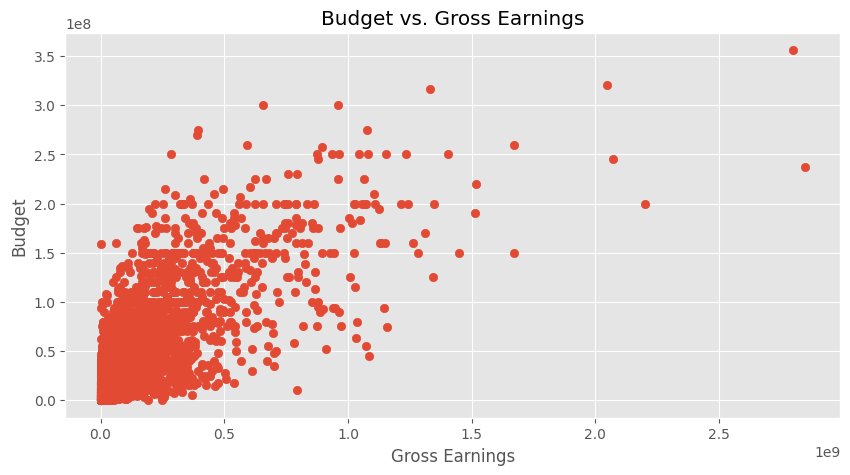

In [20]:
#I'm going to make a scatter plot 
plt.scatter(x=movies_df['gross'], y=movies_df['budget'])
plt.title('Budget vs. Gross Earnings')
plt.xlabel('Gross Earnings')
plt.ylabel('Budget')
matplotlib.rcParams['figure.figsize'] = (9,7)
plt.show()

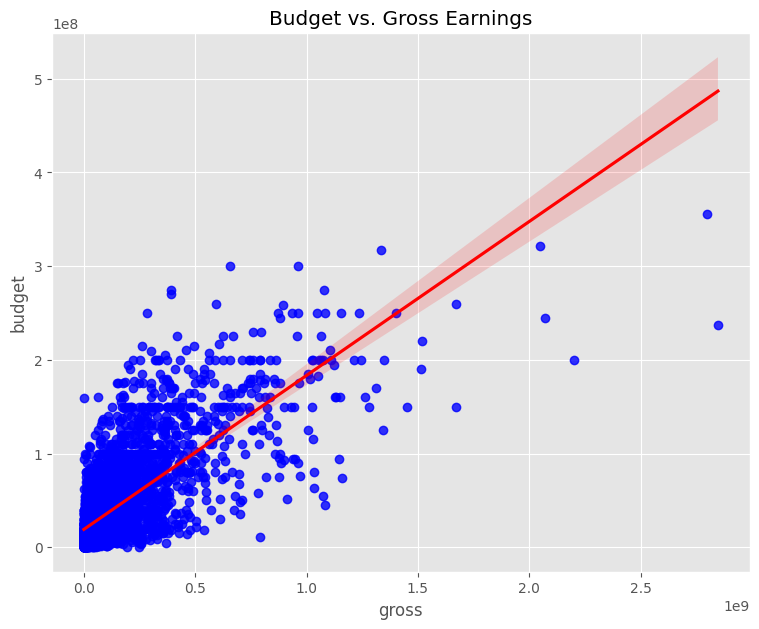

In [32]:
#Regplot using seaborn
sns.regplot(x='gross', y='budget', data=movies_df, scatter_kws={"color":"blue"}, line_kws={"color":"red"})
plt.title('Budget vs. Gross Earnings')
plt.show()

# Votes vs Gross Earnings

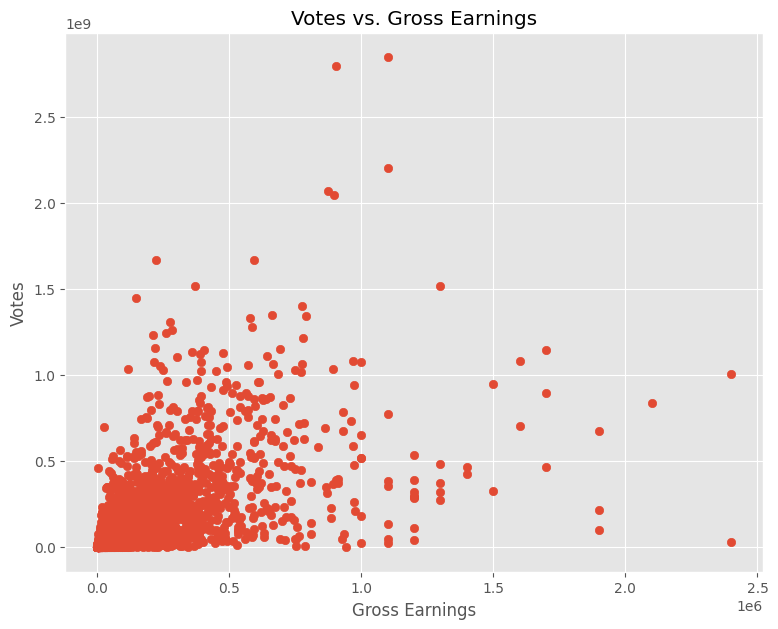

In [33]:
plt.scatter(x=movies_df['votes'], y=movies_df['gross'])
plt.title('Votes vs. Gross Earnings')
plt.xlabel('Gross Earnings')
plt.ylabel('Votes')
matplotlib.rcParams['figure.figsize'] = (9,7)
plt.show()

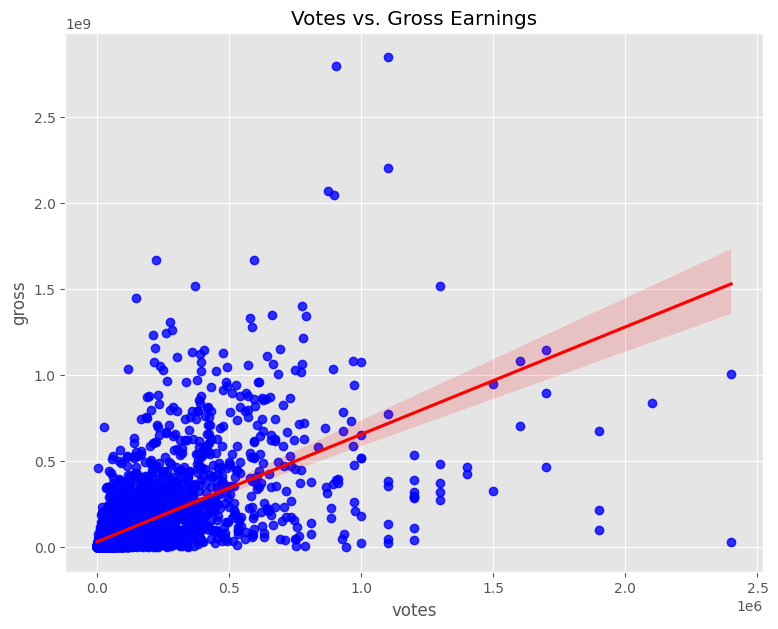

In [34]:
#Reglot for Votes and Gross Revenue Using Seaborn 
sns.regplot(x='votes', y='gross', data=movies_df, scatter_kws={"color":"blue"}, line_kws={"color":"red"})
plt.title('Votes vs. Gross Earnings')
plt.show()

# Runtime vs Gross Earnings

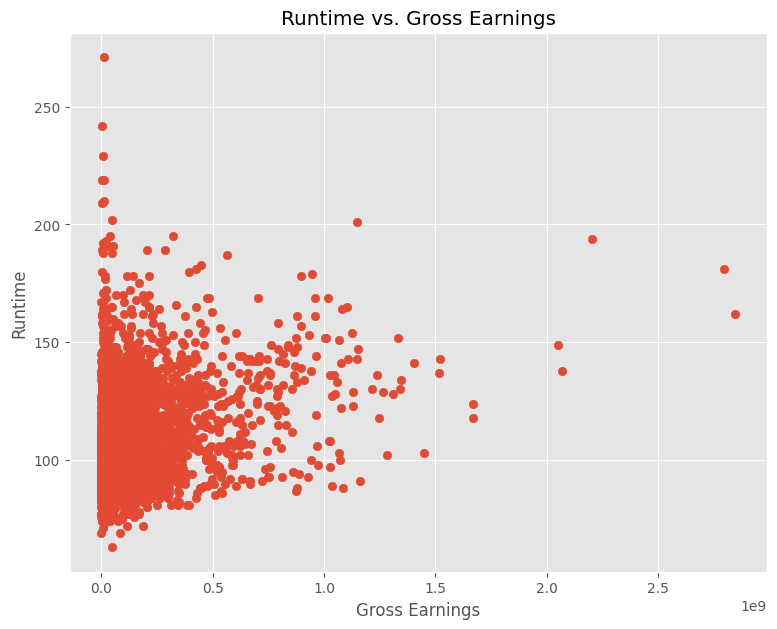

In [35]:
plt.scatter(x=movies_df['gross'], y=movies_df['runtime'])
plt.title('Runtime vs. Gross Earnings')
plt.xlabel('Gross Earnings')
plt.ylabel('Runtime')
matplotlib.rcParams['figure.figsize'] = (9,7)
plt.show()

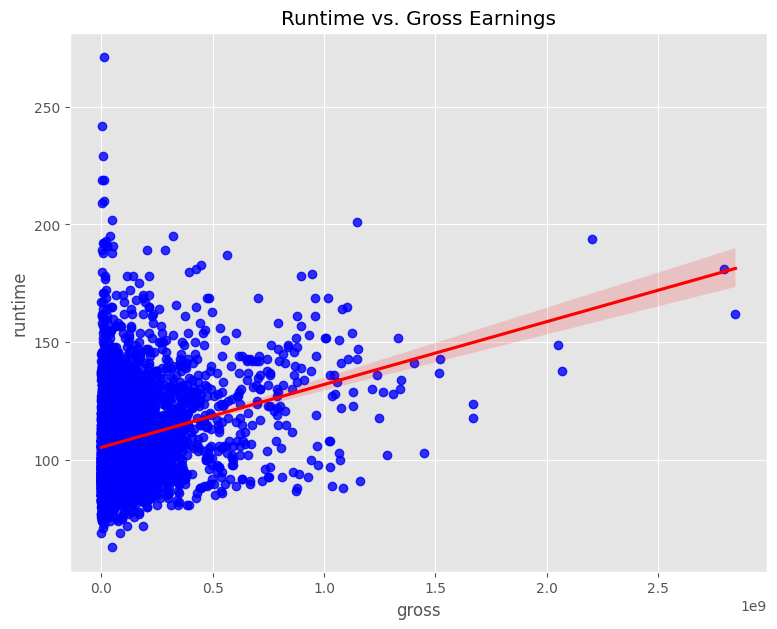

In [36]:
#Plot for Runtime and Gross Revenue Using Seaborn 
sns.regplot(x='gross', y='runtime', data=movies_df, scatter_kws={"color":"blue"}, line_kws={"color":"red"})
plt.title('Runtime vs. Gross Earnings')
plt.show()

In [24]:
movies_df.corr(numeric_only=True)

,year,score,votes,budget,gross,runtime
year,1.000000,0.057013,0.206021,0.327722,0.274321,0.075077
score,0.057013,1.000000,0.455808,0.066443,0.211973,0.394589
votes,0.206021,0.455808,1.000000,0.439675,0.614751,0.352303
budget,0.327722,0.066443,0.439675,1.000000,0.740247,0.318695
gross,0.274321,0.211973,0.614751,0.740247,1.000000,0.275796
runtime,0.075077,0.394589,0.352303,0.318695,0.275796,1.000000


# Correlation Analysis

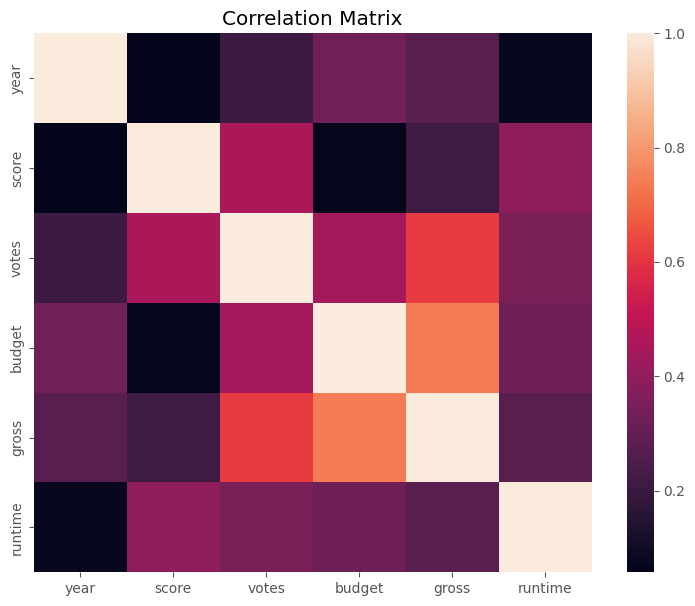

In [37]:
correlation_matrix=movies_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix)
plt.title('Correlation Matrix')
plt.show()

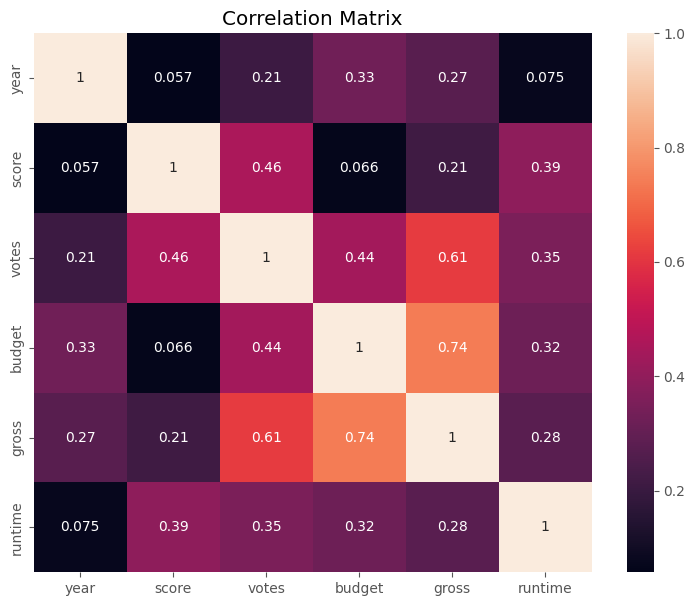

In [39]:
#Only because I want to see how it looks 
correlation_matrix=movies_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,  annot=True)
plt.title('Correlation Matrix')
plt.show()

# Key Insights 

- Budget and gross earnings show a strong positive correlation
- Votes are moderately correlated with gross revenue
- Runtime has weak correlation with earnings

# Conclusion

Higher budget films tend to generate higher revenue, but other factors like audience engagement (votes) also play a role.